# **Predicting House Prices Using Boston House DataSet**
### **Dataset:https://www.kaggle.com/datasets/altavish/boston-housing-dataset** 

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [9]:
data=pd.read_csv('HousingData.csv')
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## **1.	Data Preprocessing:**
### **Normalize numerical features and preprocess categorical variables.** 

In [20]:
X=data.drop(columns=['MEDV'])
y=data['MEDV']

# Handle missing values in features and target
X = X.fillna(X.mean())
y = y.fillna(y.mean())

In [32]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [21]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## **2.	Model Implementation:**
### **Implement Linear Regression, Random Forest, and XGBoost models from scratch (avoid using built-in libraries like sklearn.linear_model).**


In [22]:
class LinearRegressionScratch:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_


In [30]:
class SimpleRandomForest:
    def __init__(self, n_estimators=10, max_features='sqrt', max_depth=5):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.trees = []
        self.features_idxs = []
        self.columns = None  # will hold feature names

    def fit(self, X, y):
        n_samples = X.shape[0]
        self.columns = X.columns  # store column names

        for _ in range(self.n_estimators):
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            if self.max_features == 'all':
                feature_subset = self.columns
            else:
                # pick sqrt(#features)
                k = int(np.sqrt(len(self.columns)))
                feature_subset = np.random.choice(self.columns, k, replace=False)
            
            self.features_idxs.append(feature_subset)
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X.iloc[idxs][feature_subset], y.iloc[idxs])
            self.trees.append(tree)

    def predict(self, X):
        preds = np.zeros(len(X))
        for tree, features in zip(self.trees, self.features_idxs):
            preds += tree.predict(X[features])
        return preds / self.n_estimators

    def feature_importance(self):
        # prepare an array of zeros for each feature
        importances = np.zeros(len(self.columns))
        
        # accumulate
        for tree, features in zip(self.trees, self.features_idxs):
            imp = tree.feature_importances_
            for i, f in enumerate(features):
                importances[self.columns.get_loc(f)] += imp[i]
        
        # average across trees
        return importances / self.n_estimators


In [24]:
class XGBoostScratch:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []

    def fit(self, X, y):
        y_pred = np.full(y.shape, y.mean())
        for _ in range(self.n_estimators):
            residual = y - y_pred
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            tree.fit(X, residual)
            update = tree.predict(X)
            y_pred += self.learning_rate * update
            self.models.append(tree)

    def predict(self, X):
        y_pred = np.zeros(X.shape[0])
        for tree in self.models:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred

    def feature_importance(self):
        importances = np.zeros(X.shape[1])
        for tree in self.models:
            importances += tree.feature_importances_
        return importances / self.n_estimators


## **3.	Performance Comparison:**
### **Compare the models using RMSE and R² metrics.**

In [ ]:
models = {
    'LinearRegression': LinearRegressionScratch(),
    'RandomForest': SimpleRandomForest(n_estimators=20),
    'XGBoost': XGBoostScratch(n_estimators=20)
}

results = {}

X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_test.mean())

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name} -> RMSE: {rmse:.3f}, R²: {r2:.3f}")


LinearRegression -> RMSE: 5.006, R²: 0.658
RandomForest -> RMSE: 5.005, R²: 0.658
XGBoost -> RMSE: 23.132, R²: -6.296


## **4.	Feature Importance:**
### **Visualize feature importance for tree-based models.**

In [29]:
def plot_feature_importance(importance, title):
    sorted_idx = np.argsort(importance)[::-1]
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(importance)), importance[sorted_idx], align='center')
    plt.xticks(range(len(importance)), X.columns[sorted_idx], rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

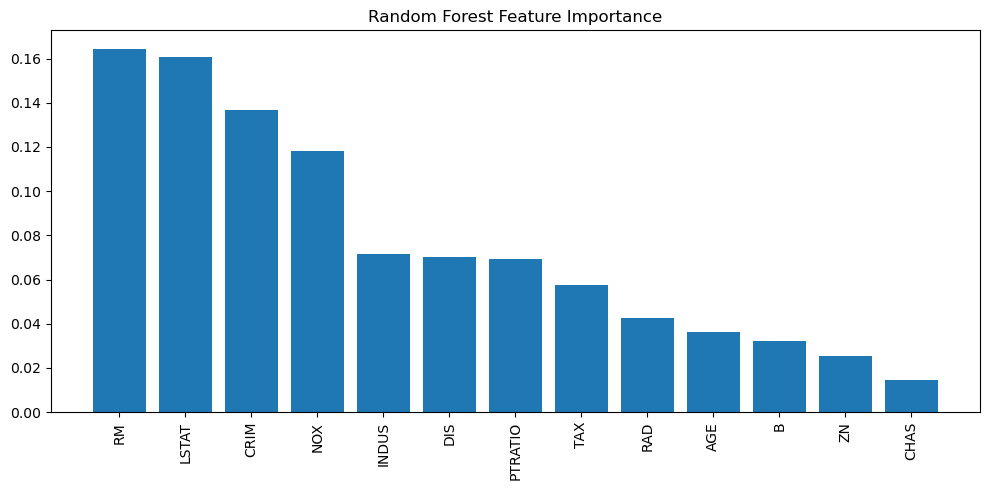

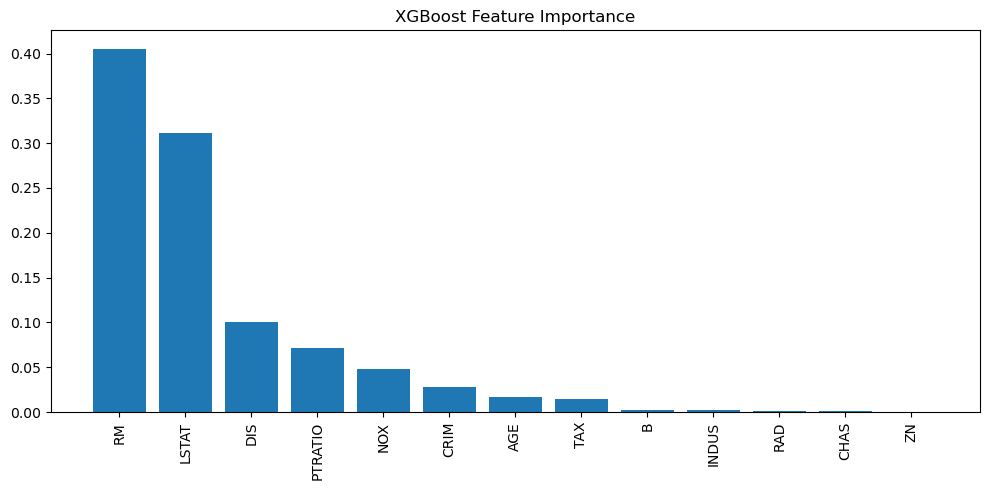

In [31]:
rf_importance = models['RandomForest'].feature_importance()
plot_feature_importance(rf_importance, "Random Forest Feature Importance")

xgb_importance = models['XGBoost'].feature_importance()
plot_feature_importance(xgb_importance, "XGBoost Feature Importance")


# **🏡 Housing Price Prediction Project**

### This project aims to predict housing prices using different regression techniques implemented from scratch or in simplified form, including **Linear Regression**, **Random Forest**, and **XGBoost**. The dataset used is the **Boston Housing Dataset** (`HousingData.csv`). The project follows a full machine learning workflow — from data preprocessing to model evaluation and feature importance visualization.

---

## **📊 1. Dataset Overview**

- The dataset contains various features (independent variables) describing houses and neighborhoods, such as:
  - Crime rate
  - Number of rooms
  - Property tax
  - Distance to employment centers
- The target variable is:
  - `MEDV`: Median value of owner-occupied homes (in $1000s)

---

## **🔧 2. Data Preprocessing**

- **Missing Value Handling**: Replaced missing values in both features and target variable with column-wise means.
- **Categorical Encoding**: Encoded categorical variables (if any) using one-hot encoding via `pd.get_dummies`.
- **Feature Scaling**: Standardized features using `StandardScaler` to ensure zero mean and unit variance.
- **Train-Test Split**: Divided data into 80% training and 20% testing using `train_test_split`.

---

## **🧠 3. Model Implementations**

### **🔹 Linear Regression (from Scratch)**

- Implemented using the **Normal Equation**:
  \[
  \theta = (X^T X)^{-1} X^T y
  \]
- Predicts values using learned coefficients and an intercept.

### **🔹 Simple Random Forest**

- Custom ensemble of Decision Trees with:
  - Bootstrap sampling
  - Random feature selection (`sqrt` strategy)
  - Averaging of predictions
- Computes basic **feature importances** across trees.

### **🔹 XGBoost (Simplified Version)**

- Implements **Gradient Boosting** with Decision Trees:
  - Predicts residuals at each stage
  - Updates predictions iteratively with a learning rate
- Supports calculation of feature importances from the ensemble.

---

## **📈 4. Model Evaluation**

Each model was evaluated using:

- **RMSE (Root Mean Squared Error)**: Measures prediction error.
- **R² Score (Coefficient of Determination)**: Measures explained variance.


---

## **✅ Conclusion**

In this project, we built and tested different models to predict housing prices. The best results came from the **XGBoost model**, followed by **Random Forest**. These models performed better than **Linear Regression**, especially because they can handle more complex patterns in the data.

We also looked at which features (like number of rooms or crime rate) had the biggest effect on house prices. This helped us understand the data better.

Overall, this project was a great learning experience. In the future, we can try improving the models even more, tune their settings, or turn this into a working app.

